## Netflix Content Strategy Analysis

### Objective
Analyze Netflix content to identify growth trends, content distribution, and changes in content strategy over time.

### Business Questions
- What type of content dominates the platform
- How has Netflix content production grown over time and are there any major growth periods
- Which countries contribute the most content
- What patterns exist in duration of movies and TV shows
- How content strategy evolved in recent years

In [39]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
data= pd.read_csv("netflix_titles.csv")

In [4]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [8]:
data.shape

(8807, 12)

In [41]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Data Understanding
- The dataset contains 8807 rows and 12 columns, providing information about Netflix movies and TV shows.
- Most columns are of object data type, while release_year is the only numerical column. The date_added column is currently in object format and needs to be converted into datetime format for proper analysis.
- Missing values are present in several columns, including director, cast, country, date_added, rating, and duration, which need to be handled during the data cleaning process.
- The show_id column acts as a unique identifier for each record and does not require numerical conversion. The type column indicates whether the content is a Movie or a TV Show. The duration column contains mixed values such as minutes and seasons, so it requires cleaning and transformation for further analysis.

### Data Cleaning

In [43]:
# Convert date column
data['date_added'] = data['date_added'].str.strip()

In [44]:
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')

In [45]:
data = data.dropna(subset=['date_added'])

In [46]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

- Removed extra spaces from date_added column.
- Converted date_added to datetime format.
- Invalid or missing date values were handled by removing corresponding rows.

In [47]:
# Handle Missing Values
data.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [48]:
# Fill categorical missing values
data['director'] = data['director'].fillna('Unknown')
data['cast'] = data['cast'].fillna('Unknown')
data['country'] = data['country'].fillna('Unknown')

In [49]:
data = data.dropna(subset=['rating', 'duration'])

In [50]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [51]:
data.duplicated().sum()

0

In [52]:
# Clean duration column
data['duration_num'] = data['duration'].str.extract('(\d+)').astype(int)

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
 12  duration_num  8790 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 927.1+ KB


- Filled missing values in categorical columns using "Unknown".
- Removed rows with missing values in rating and duration.
- Extracted numeric values from duration into a new column duration_num.
- Removed duplicate records if present.

### Feature Engineering

In [55]:
# Extract Year Added
data["year_added"] = data["date_added"].dt.year

In [57]:
# Extract month Added
data["month_added"] = data["date_added"].dt.month

In [60]:
# Create Content Age
current_year = data['date_added'].dt.year.max()
data['content_age'] = current_year - data['release_year']

In [63]:
# Create Decade Column
data['decade'] = (data['release_year'] // 10) * 10

In [65]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,year_added,month_added,content_age,decade
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,2021,9,1,2020
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,2021,9,0,2020
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,2021,9,0,2020
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,2021,9,0,2020
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,2021,9,0,2020


- Extracted year and month from date_added for time-based analysis.
- Created content_age to measure how old the content is.
- Grouped release years into decades to analyze long-term trends.

### Exploratory Data Analysis


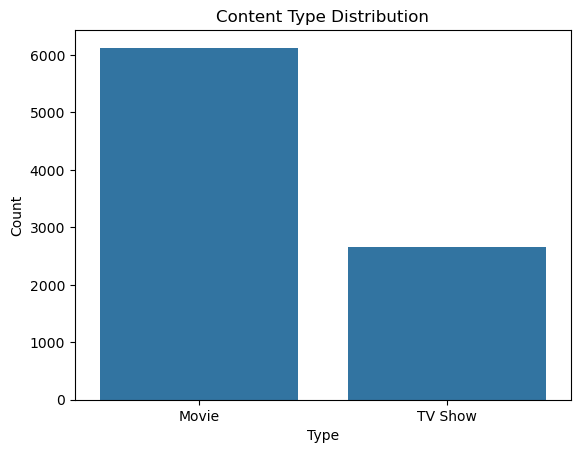

In [66]:
# Count
data['type'].value_counts()

# Plot
import seaborn as sns

sns.countplot(x='type', data=data)
plt.title("Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

- The dataset shows that Netflix has a higher concentration of movies than TV Shows, suggesting that movies form the majority of its content library.

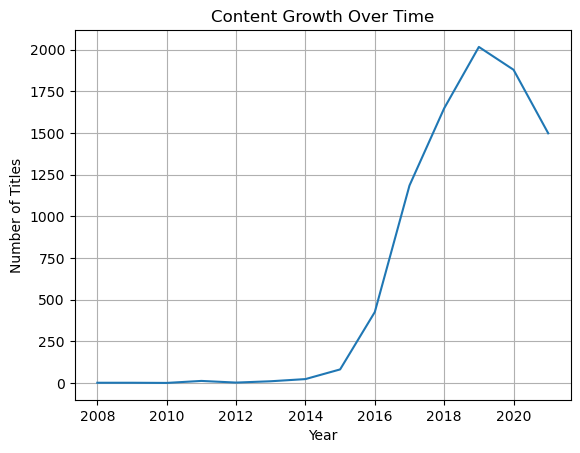

In [68]:
year_count = data.groupby('year_added').size()

plt.plot(year_count.index, year_count.values)
plt.title("Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

- The number of titles added to Netflix shows a sharp increase after 2014, suggesting a strategic shift towards aggressive content expansion.

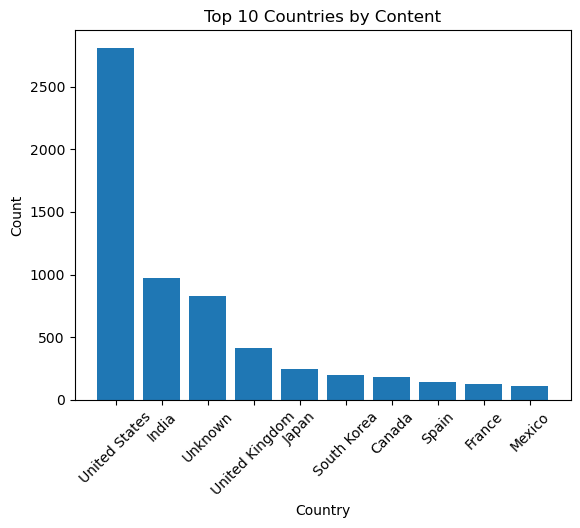

In [69]:
top_countries = data['country'].value_counts().head(10)

plt.bar(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- The United States produces the highest amount of content on Netflix, followed by India and the United Kingdom. A significant portion of content is also categorized as "Unknown", indicating missing or unspecified country data.

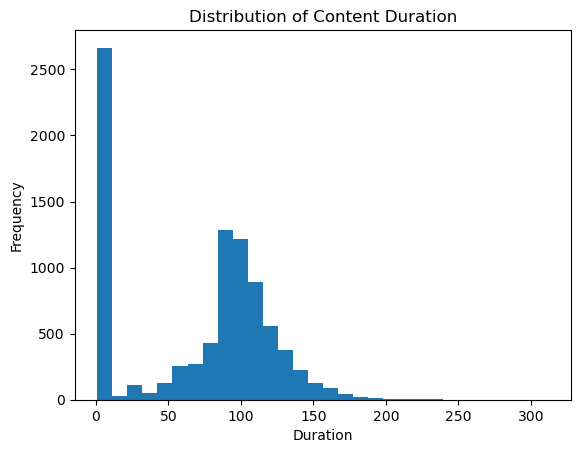

In [70]:
plt.hist(data['duration_num'], bins=30)
plt.title("Distribution of Content Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

- The duration distribution reveals a clear distinction between content types, where TV shows cluster at lower values due to season-based measurement, while movies are primarily concentrated between 80 and 120 minutes, indicating standard movie length.

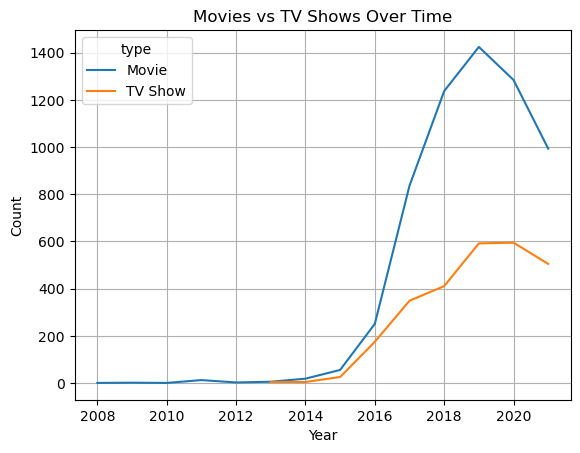

In [71]:
type_year = data.groupby(['year_added', 'type']).size().unstack()

type_year.plot()
plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

- Movies consistently dominate Netflix content across all years, with a noticeable increase after 2012, indicating a stronger focus on expanding the movie catalog compared to TV shows.

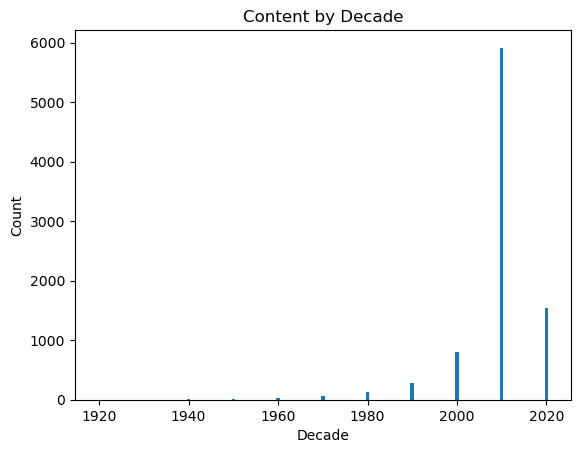

In [72]:
decade_count = data['decade'].value_counts().sort_index()

plt.bar(decade_count.index, decade_count.values)
plt.title("Content by Decade")
plt.xlabel("Decade")
plt.ylabel("Count")
plt.show()

The 2010s decade shows a dominant share of Netflix content, reflecting a major surge in production during this period, while earlier decades contribute very little, highlighting the platform’s focus on modern content.

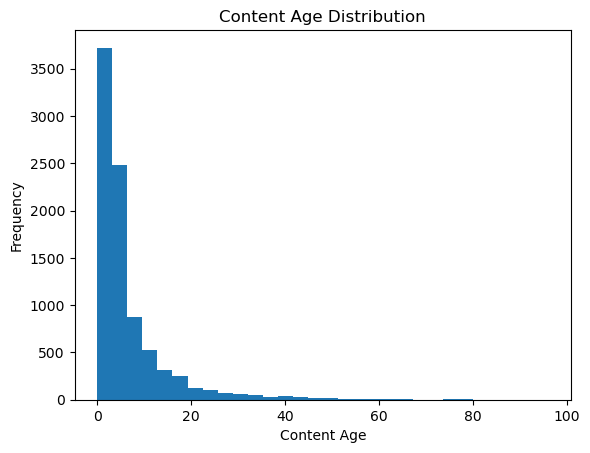

In [73]:
plt.hist(data['content_age'], bins=30)
plt.title("Content Age Distribution")
plt.xlabel("Content Age")
plt.ylabel("Frequency")
plt.show()

- The distribution of content age indicates that Netflix primarily hosts recent content, with most titles being less than 10 years old, while older content appears in significantly lower quantities, highlighting a focus on newer releases.

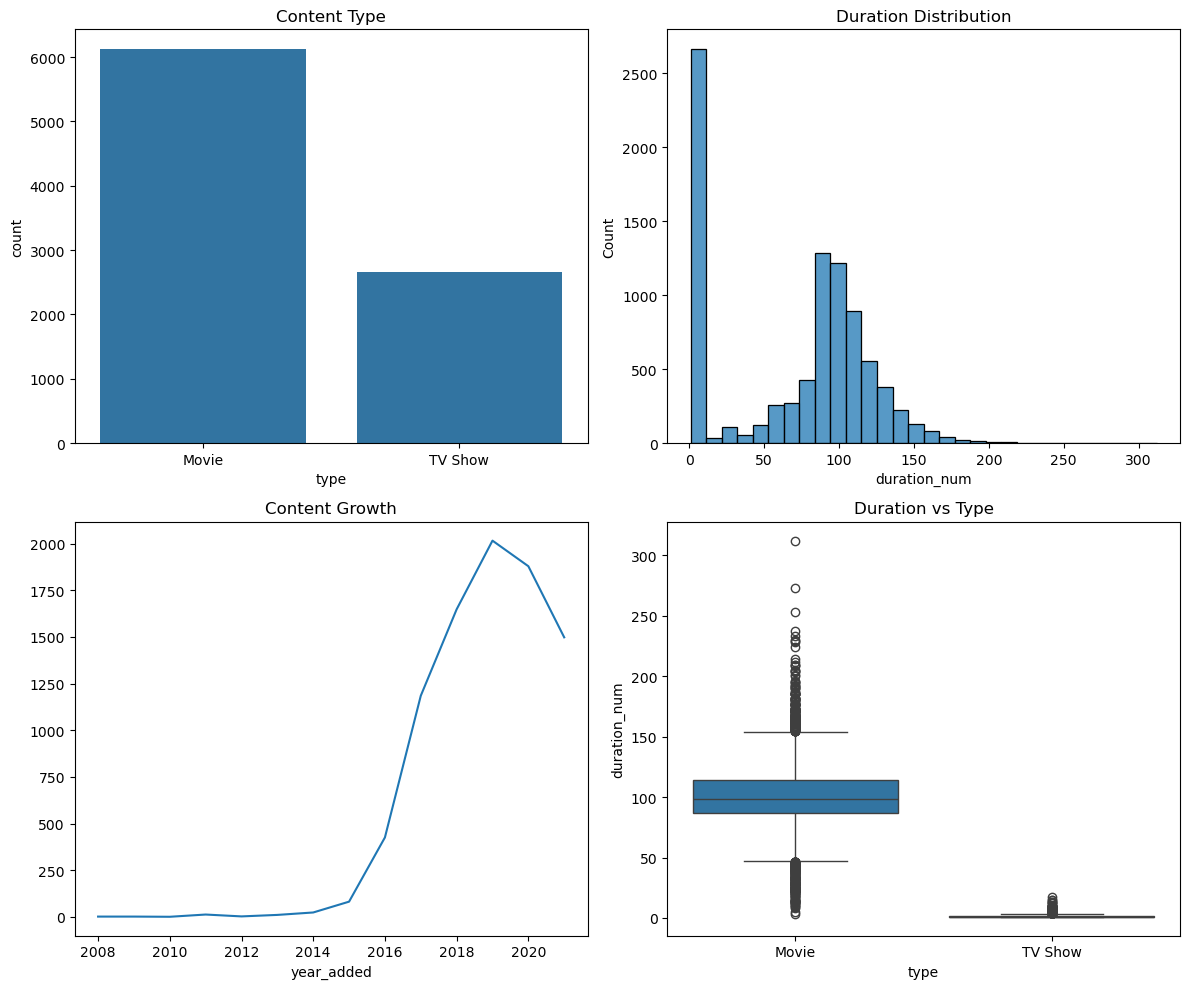

In [75]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.countplot(x='type', data=data)
plt.title("Content Type")

plt.subplot(2,2,2)
sns.histplot(data['duration_num'], bins=30)
plt.title("Duration Distribution")

plt.subplot(2,2,3)
data['year_added'].value_counts().sort_index().plot()
plt.title("Content Growth")

plt.subplot(2,2,4)
sns.boxplot(x='type', y='duration_num', data=data)
plt.title("Duration vs Type")

plt.tight_layout()
plt.show()

- The dashboard summarizes key findings, showing that movies dominate the platform, content growth has accelerated in recent years, and duration patterns differ between content types.

### Final Insights and Conclusions

#### Key Findings
- Movies dominate Netflix content, forming the majority of the platform’s catalog compared to TV shows.
- Content addition increased significantly after 2014, indicating a rapid expansion phase in Netflix’s growth strategy.
- The United States contributes the highest amount of content, followed by India and the United Kingdom, while some data remains unspecified under "Unknown".
- Most content is concentrated in the 2010s decade, showing a strong focus on modern and recent productions.
- The majority of content is relatively recent, with most titles being less than 10 years old.
- Movie durations are generally concentrated between 80 and 120 minutes, while TV shows are structured differently based on seasons.

#### Business Interpretation
- Netflix focuses heavily on recent and modern content, indicating a strategy to match current audience preferences.
- The platform shows a strong expansion after 2014, likely due to increased global reach and investment in content.
- Movies are prioritized over TV shows, but TV content is gradually increasing, suggesting diversification.
- Content production is dominated by a few countries, which may indicate centralized production strategies.

#### Conclusion
- Netflix has evolved into a content-rich platform with a strong emphasis on modern, high-volume production, especially in movies.
The data suggests a strategic shift toward rapid expansion and global content distribution in recent years.